# Comparing Unsmoothed and Basic SSHA

In [1]:
from pathlib import Path
import glob
import numpy as np
import netCDF4 as nc
import xarray as xr

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cm
from swot_analysis import plotting



In [2]:
#Reading a single file
data_dir = '/Users/zoecas/Documents/data/'
filename_basic = 'SWOT_L2_LR_SSH_BASIC_D_D-20260603_062409/SWOT_L2_LR_SSH_Basic_044_098_20260106T210232_20260106T215400_PID0_01.nc'
filename_unsmooth = 'SWOT_L2_LR_SSH_Unsmoothed_044_098_20260106T210233_20260106T215359_PID0_01.nc'    


In [3]:
#we need to select a group when opening unsmoothed data
with nc.Dataset(data_dir+filename_unsmooth, "r") as nc:
    print("Available groups:", list(nc.groups.keys()))

Available groups: ['left', 'right']


In [4]:
ds_unsmooth_left = xr.open_dataset(data_dir+filename_unsmooth, group='left')
ds_unsmooth_right = xr.open_dataset(data_dir+filename_unsmooth, group='right')
ds_unsmooth_left

<xarray.Dataset> Size: 4GB
Dimensions:                                (num_lines: 83016, num_pixels: 240,
                                            num_doppler_miti_lines: 10481,
                                            num_doppler_miti_pixels: 24)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 159MB ...
    longitude                              (num_lines, num_pixels) float64 159MB ...
    latitude_doppler_miti                  (num_doppler_miti_lines, num_doppler_miti_pixels) float64 2MB ...
    longitude_doppler_miti                 (num_doppler_miti_lines, num_doppler_miti_pixels) float64 2MB ...
Dimensions without coordinates: num_lines, num_pixels, num_doppler_miti_lines,
                                num_doppler_miti_pixels
Data variables: (12/30)
    time                                   (num_lines) datetime64[ns] 664kB ...
    time_tai                               (num_lines) datetime64[ns] 664kB ...
    latitude_uncert                        (num_lines, num_pixels) float64 159MB ...
    longitude_uncert                       (num_lines, num_pixels) float64 159MB ...
    ssh_karin                              (num_lines, num_pixels) float64 159MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 159MB ...
    ...                                     ...
    volumetric_correlation_uncert          (num_lines, num_pixels) float64 159MB ...
    total_coherence                        (num_lines, num_pixels) float64 159MB ...
    time_doppler_miti                      (num_doppler_miti_lines) datetime64[ns] 84kB ...
    time_tai_doppler_miti                  (num_doppler_miti_lines) datetime64[ns] 84kB ...
    geophysical_doppler_miti               (num_doppler_miti_lines, num_doppler_miti_pixels) float64 2MB ...
    surface_velocity_doppler_miti          (num_doppler_miti_lines, num_doppler_miti_pixels) float64 2MB ...
Attributes:
    description:  Unsmoothed SSH measurement data and related information for...

In [5]:
ds_basic = xr.open_dataset(data_dir+filename_basic)
ds_basic

<xarray.Dataset> Size: 112MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 5MB ...
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 5MB ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2026-01-08T16:17:27Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       67.80712455934498
    ssha_variance:                                 0.026332454950334927
    references:                                    V1.4.1
    equator_longitude:                             4.50

(-20.0, 34.86395199999998)

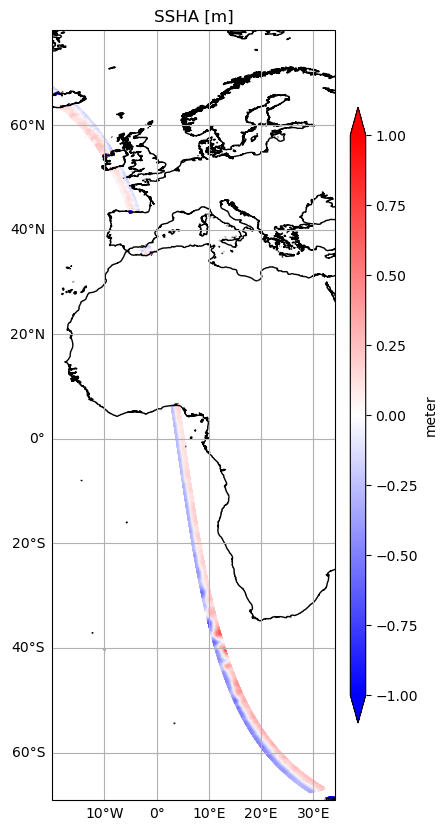

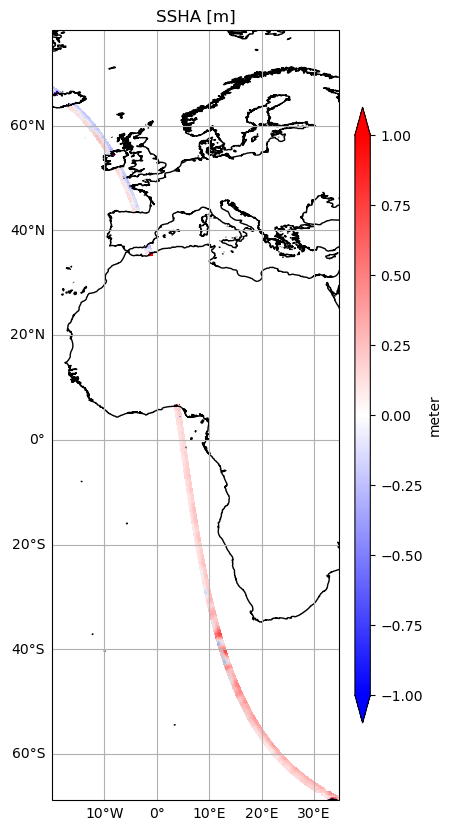

In [6]:
# Basic
title = 'SSHA [m]'
dat = ds_basic.ssha_karin.where(np.isnan(ds_basic.ssha_karin)==False).values
lon = ds_basic.longitude.where(np.isnan(dat)==False).values
lat = ds_basic.latitude.where(np.isnan(dat)==False).values
vmin, vmax = -1,1

lonmax = ((ds_basic.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((ds_basic.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,lonmax)

dat = ds_unsmooth_left.ssha_karin.where(np.isnan(ds_unsmooth_left.ssha_karin)==False).values
lon = ds_unsmooth_left.longitude.where(np.isnan(dat)==False).values
lat = ds_unsmooth_left.latitude.where(np.isnan(dat)==False).values
vmin, vmax = -1,1

lonmax = ((ds_unsmooth_left.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((ds_unsmooth_left.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,lonmax)

In [22]:
def zoom(ds,lon_min,lon_max,lat_min,lat_max):
    lon_normalized = (ds["longitude"] + 180) % 360 - 180
    geo_mask = (
        (lon_normalized >= lon_min)
        & (lon_normalized <= lon_max)
        & (ds["latitude"] >= lat_min)
        & (ds["latitude"] <= lat_max)
    )
    return geo_mask
    
lon_min,lon_max = 10,25
lat_min,lat_max = -60,-40
sub_vars = ["ssha_karin","height_cor_xover","latitude","longitude"]


geo_mask = zoom(ds_unsmooth_left[sub_vars],lon_min,lon_max,lat_min,lat_max)
unsmoothl_zoom = ds_unsmooth_left[sub_vars].where(geo_mask, drop=True)

geo_mask = zoom(ds_unsmooth_right[sub_vars],lon_min,lon_max,lat_min,lat_max)
unsmoothr_zoom = ds_unsmooth_right[sub_vars].where(geo_mask, drop=True)

geo_mask = zoom(ds_basic[sub_vars],lon_min,lon_max,lat_min,lat_max)
basic_zoom = ds_basic[sub_vars].where(geo_mask, drop=True)

In [17]:
ssha_basic = (basic_zoom.ssha_karin + basic_zoom.height_cor_xover)
ssha_unsmoothr = (unsmoothr_zoom.ssha_karin + unsmoothr_zoom.height_cor_xover)
ssha_unsmoothl = (unsmoothl_zoom.ssha_karin + unsmoothl_zoom.height_cor_xover)

AttributeError: 'DataArray' object has no attribute 'ssha_karin'

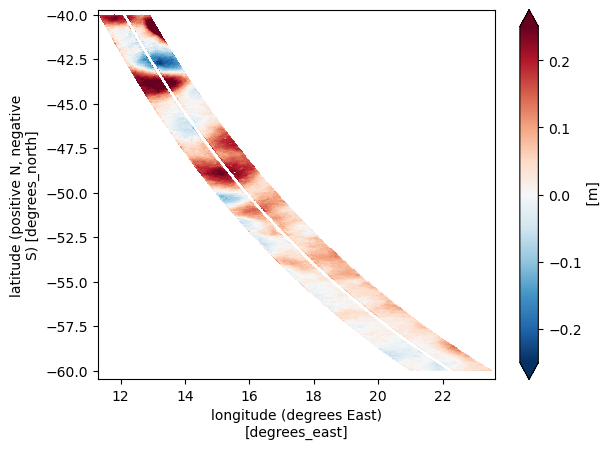

In [27]:
fig,axs = plt.subplots(1,3,figsize=(15,5))
ssha_basic.plot(x='longitude',y='latitude',vmax=0.25,ax=axs[0])
ssha_unsmoothl.plot(x='longitude',y='latitude',vmax=0.25,ax=axs[1])
ssha_unsmoothr.plot(x='longitude',y='latitude',vmax=0.25,ax=axs[2])

ValueError: 'c' argument has 680754 elements, which is inconsistent with 'x' and 'y' with size 19923840.

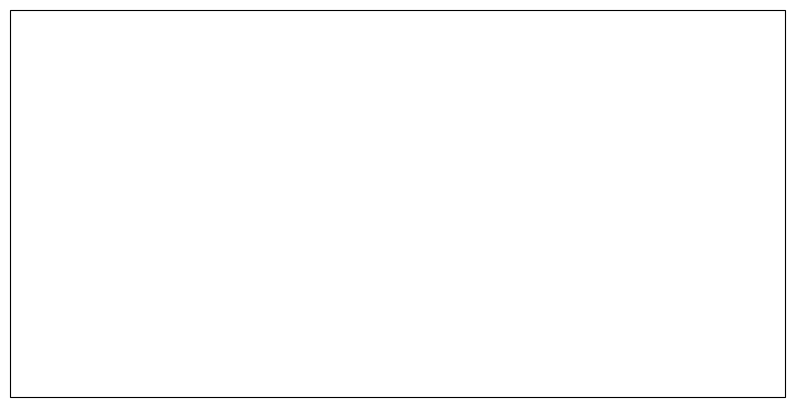

In [10]:
# Correcting the crossover bias using exisitng height correction in Basic files
dat = (ds_basic.ssha_karin + ds_basic.height_cor_xover).values

vmin, vmax = -0.25,0.25

lonmax = ((ds_basic.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((ds_basic.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)

#dat = (ds_unsmooth_left.ssha_karin + ds_unsmooth_left.height_cor_xover).values#

#vmin, vmax = -0.25,0.25

#lonmax = ((ds_unsmooth_left.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
#lonmin = ((ds_unsmooth_left.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
#ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
#ax.set_xlim(10,25)
#ax.set_ylim(-60,-40)

(-60.0, -40.0)

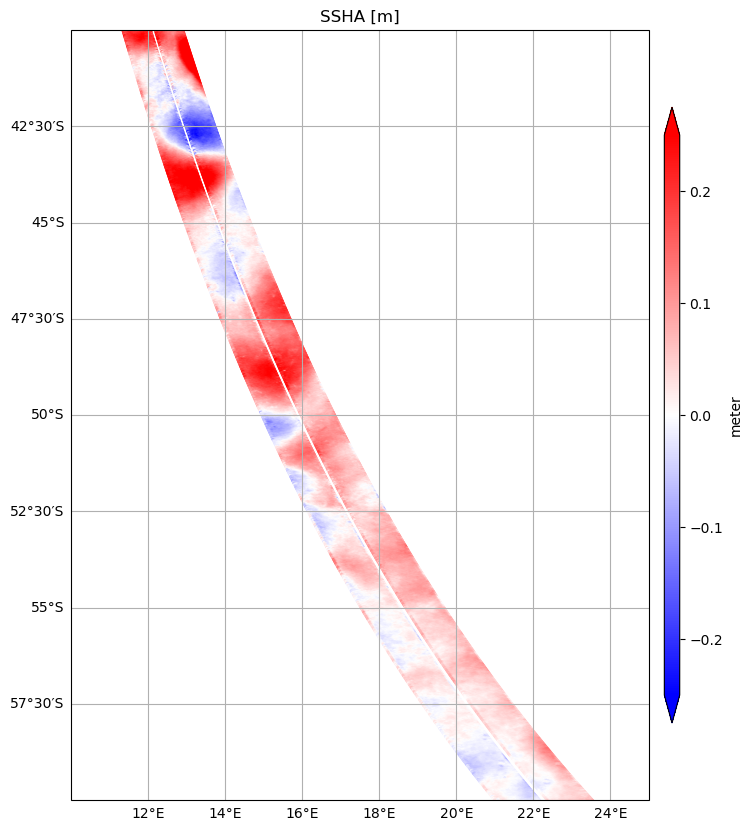

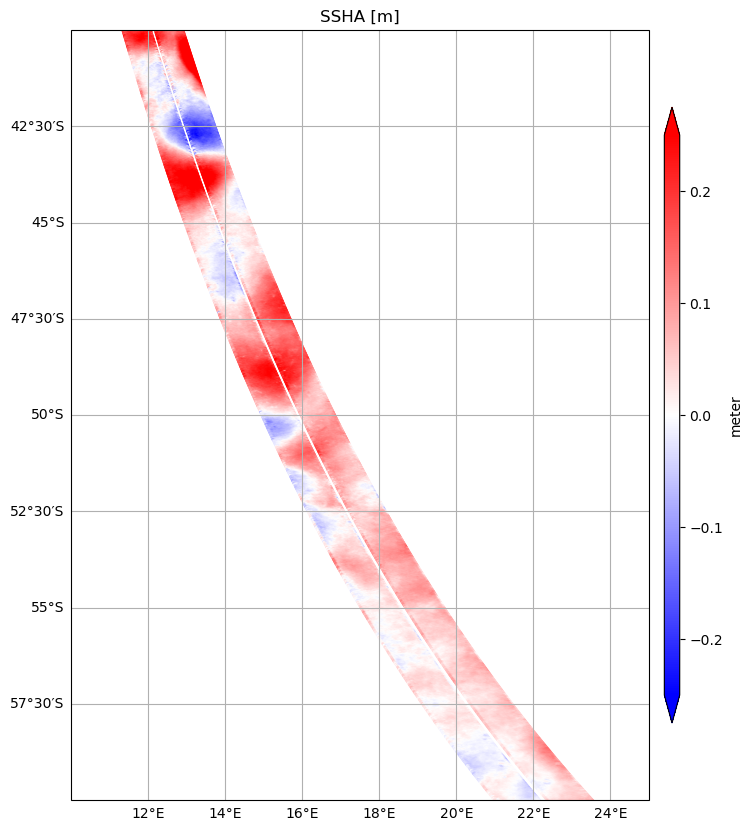

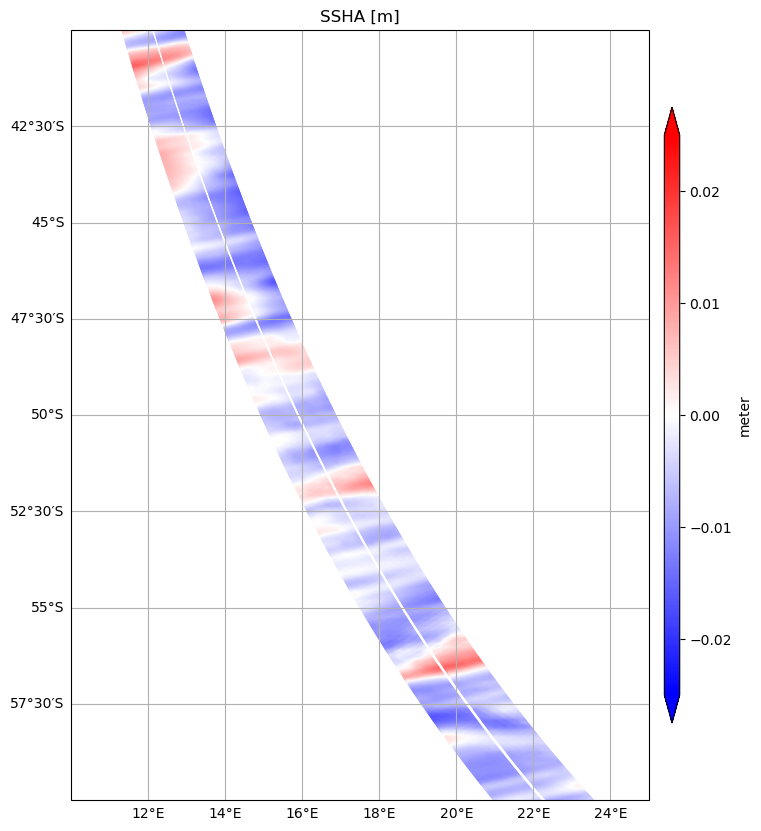

In [19]:


dat = (test.ssha_karin_2 + test.height_cor_xover).values

vmin, vmax = -0.25,0.25

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)

dat = (test.ssha_karin-test.ssha_karin_2).values

vmin, vmax = -0.025,0.025

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)

(50.0, 65.0)

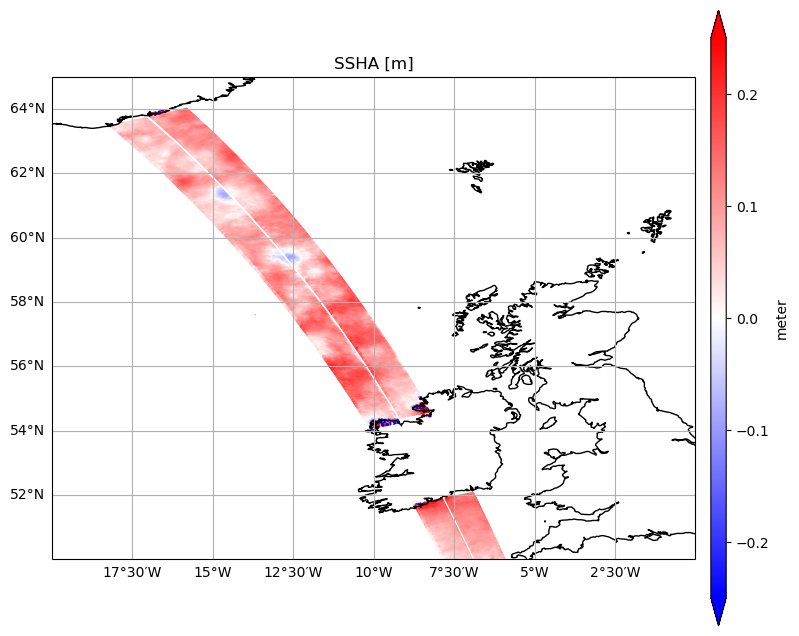

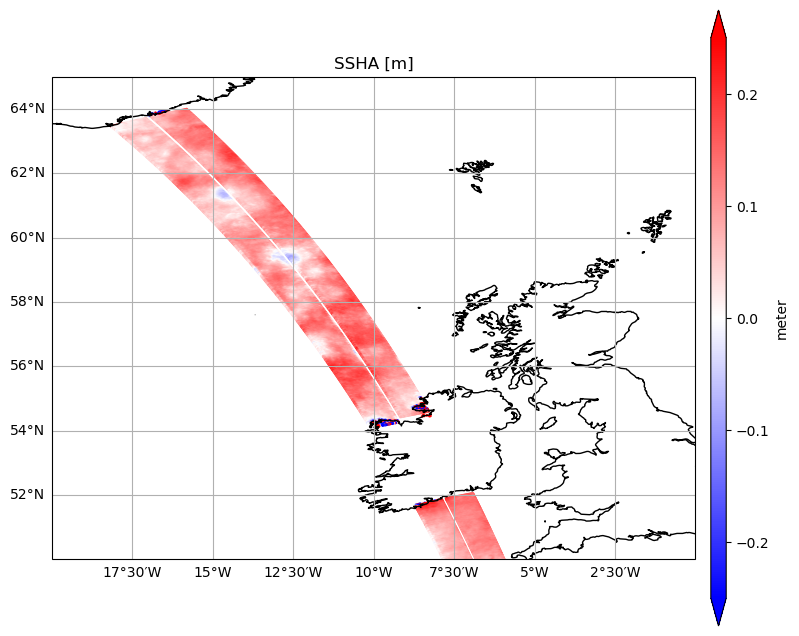

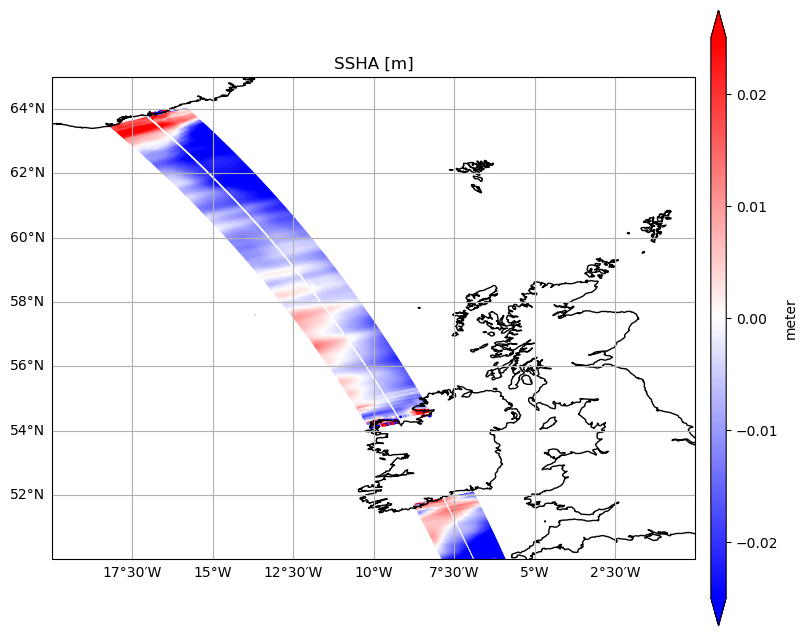

In [20]:
# Same analysis south of Iceland
dat = (test.ssha_karin + test.height_cor_xover).values

vmin, vmax = -0.25,0.25

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,0)
ax.set_ylim(50,65)

dat = (test.ssha_karin_2 + test.height_cor_xover).values

vmin, vmax = -0.25,0.25

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,0)
ax.set_ylim(50,65)

dat = (test.ssha_karin-test.ssha_karin_2).values

vmin, vmax = -0.025,0.025

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,0)
ax.set_ylim(50,65)